# Imports

In [81]:
# --- path setup ---
from sys import path  # add directory where starships is located
path.append('/home/mathisb/Github/starships')

import os  # add directory containing the input data (opacity, abundance and stellar specs files)
os.environ['pRT_input_data_path'] = '/home/mathisb/projects/def-rdoyon/shared/Models/petitRADTRANS/input_data/'

from pathlib import Path

# --- standard libraries ---
import logging
import warnings
from importlib import reload
from itertools import product

# --- scientific libraries ---
import numpy as np
from scipy.interpolate import interp1d

# --- astropy ---
import astropy.units as u
import astropy.constants as const
from astropy import stats

# --- matplotlib ---
import matplotlib.pyplot as plt
from matplotlib import cm, gridspec, set_loglevel
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase

# --- starships modules ---
from starships import homemade as hm
from starships import correlation as corr
import starships.correlation_class as cc
import starships.plotting_fcts as pf
import starships.planet_obs as pl_obs
from starships.correlation_class import Correlations
from starships.planet_obs import Observations, Planet

# --- configuration ---
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
logging.getLogger("fontTools.subset").setLevel(logging.WARNING)

couleurs = hm.get_colors('magma', 50)[5:-2]

# Correlation setup

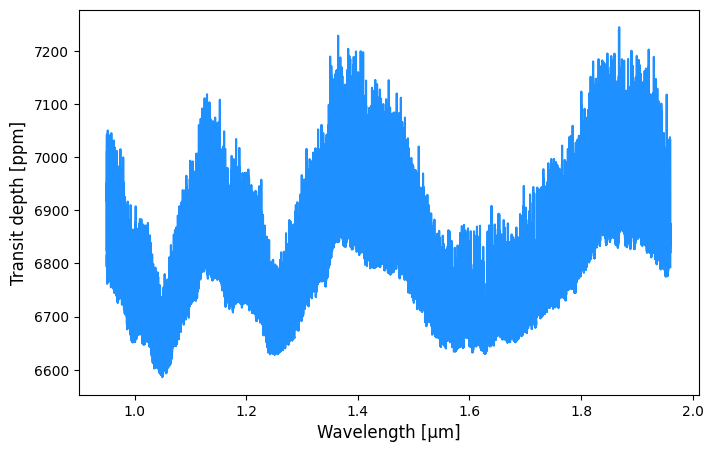

In [82]:
# BASIC INFORMATION
pl_name = "TRAPPIST-1 f"
instrument = "NIRPS_Apr2026"  # SPIRou_with_persi, NIRPS, NIRPS_Apr2026


# NIGHTS TO CROSS-CORRELATE WITH
nightlist = [
    # SPIRou b
            # "2019-06-14",
            # "2019-09-25",
            # "2020-05-31",
            # "2020-08-04",
            # "2020-09-08",
            # "2020-09-20",
            # "2020-09-26",
            # "2020-09-29",
            # "2021-10-21",
            # "2021-10-24",
            # "2021-10-27"
    # NIRPS b
            # '2023-09-07',
            # '2024-07-05',
            # '2024-07-11b',
    # NIRPS d
            # '2023-06-08',
            # '2023-08-12',
            # '2023-08-24',
            # '2023-10-20',
    # NIRPS e
            # '2023-07-17',
            # '2023-11-04',
            # '2024-07-11e',
    # NIRPS f
            '2023-08-28',
            '2024-11-02',
            '2025-08-06',
    # NIRPS g
            # '2023-10-05',
            # '2023-11-11',
            # '2025-07-08',
               ]


# MODEL DETAILS
molecule = 'H2O'
scenario = 'H2rich'
ab = 1
cloud = 100

# model_directory = "/home/mathisb/Github/HRS_models/"  # where to find the models
# model_filename_1 = "prt_model_TRAPPIST-1f"
# model_filename_2 = "CH4_NIRPS_H2rich.npz"  # CO2, CH4, H2O

# ########################### TEMP
model_directory = f"/home/mathisb/scratch/HRS_models/{pl_name[-1]}_{scenario}_{molecule}/"
model_filename_1 = f"prt_model_TRAPPIST-1{pl_name[-1]}"
model_filename_2 = f"{scenario}_{molecule}_{str(ab)}_pcloud_{str(cloud)}.npz"
# ##########################



# REDUCTION DETAILS
reduc_version = 'v001'
nPC_list = [0]

# Where are the reductions
reduc_in_scratch = True  # in the scratch directory (True) or in the home directory (False)


# CORRELATION DETAILS
kind_trans = 'transmission'  # emission or transmission

# Define cross-correlation axes
step_RV_inj = 1.0  # SPIROU: 2.14 (twice the resolution of SPIRou in km/s); NIRPS: 1.0
corr_xlim = 100  # correlation will be done with Vrad values in [-corr_xlim, corr_xlim]

# Where to output the correlations
output_in_scratch = True  # in the scratch directory (True) or in the home directory (False)


#------------------------------------------------------------------------------------------#


# Load the model
model_filename = model_filename_1 + '_' + model_filename_2
model_file = np.load(model_directory + model_filename)
wave_mod, model_spec = model_file['wave_mod'], model_file['model_spec']

if 'NIRPS' in instrument:
    # cut off the model at the NIRPS wavelengths
    model_spec = model_spec[wave_mod <= 1.96]
    wave_mod = wave_mod[wave_mod <= 1.96]

# Plot it
plt.figure(figsize=(8,5))
plt.plot(wave_mod, model_spec * 1e6, color="dodgerblue")
# plt.axhline(5 + (R_pl.to(u.R_sun).value / R_star.value) **2 * 1e6, color='r')  # plot the cutoff under which orders are rejected

plt.xlabel('Wavelength [μm]', fontsize=12)
plt.ylabel('Transit depth [ppm]', fontsize=12)  # transit depth: $(\frac{R_{\rm p}}{R_{\rm \star}})^2$
plt.show()


In [83]:
# OTHER INFORMATION

if pl_name == 'TRAPPIST-1 b':
    ap     = 0.01154*u.au        # semi-major axis of planet
    R_pl   = 1.116*u.R_earth     # radius of planet
    R_star = 0.1192*u.R_sun      # radius of star
    M_star = 0.0898*const.M_sun  # mass of star
    e      = 0                   # eccentricity
    w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)

elif pl_name == 'TRAPPIST-1 d':
    ap     = 0.02227*u.au        # semi-major axis of planet
    R_pl   = 0.788*u.R_earth     # radius of planet
    R_star = 0.1192*u.R_sun      # radius of star
    M_star = 0.0898*const.M_sun  # mass of star
    e      = 0                   # eccentricity
    w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)

elif pl_name == 'TRAPPIST-1 e':
    ap     = 0.02925*u.au        # semi-major axis of planet
    R_pl   = 0.920*u.R_earth     # radius of planet
    R_star = 0.1192*u.R_sun      # radius of star
    M_star = 0.0898*const.M_sun  # mass of star
    e      = 0                   # eccentricity
    w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)

elif pl_name == 'TRAPPIST-1 f':
    ap     = 0.03849*u.au        # semi-major axis of planet
    R_pl   = 1.045*u.R_earth     # radius of planet
    R_star = 0.1192*u.R_sun      # radius of star
    M_star = 0.0898*const.M_sun  # mass of star
    e      = 0                   # eccentricity
    w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)

elif pl_name == 'TRAPPIST-1 g':
    ap     = 0.04683*u.au        # semi-major axis of planet
    R_pl   = 1.129*u.R_earth     # radius of planet
    R_star = 0.1192*u.R_sun      # radius of star
    M_star = 0.0898*const.M_sun  # mass of star
    e      = 0                   # eccentricity
    w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)

else:
    raise ValueError(f"Please add the params for planet {pl_name}.")


# Mid-transit time (BJD) of each TRAPPIST-1 visit (calculated from Agol et al. 2024)
mid_tr_dict = {
        # SPIRou b
               "2019-06-14": 2458649.07123371738 * u.d,
               "2019-09-25": 2458751.8112203472  * u.d,
               "2020-05-31": 2459001.10676193183 * u.d,
               "2020-08-04": 2459066.07481311538 * u.d,
               "2020-09-08": 2459100.82490738839 * u.d,
               "2020-09-20": 2459112.91190875796 * u.d,
               "2020-09-26": 2459118.95517847751 * u.d,
               "2020-09-29": 2459121.9775049779  * u.d,
               "2021-10-21": 2459508.76251261068 * u.d,
               "2021-10-24": 2459511.78471495466 * u.d,
               "2021-10-27": 2459514.8059938763  * u.d,
        # NIRPS b
               "2023-09-07": 2460194.7007329288  * u.d,
               "2024-07-05": 2460496.8725766301  * u.d,
               "2024-07-11b": 2460502.9159761349 * u.d,
        # NIRPS d
               "2023-06-08": 2460103.8951073092 * u.d,
               "2023-08-12": 2460168.6902942523 * u.d,
               "2023-08-24": 2460180.8397053848 * u.d,
               "2023-10-20": 2460237.5365671548 * u.d,
        # NIRPS e
               "2023-07-17": 2460142.858565431  * u.d,
               "2023-11-04": 2460252.6376593957 * u.d,
               "2024-07-11e": 2460502.7365562134 * u.d,
        # NIRPS f
               "2023-08-28": 2460184.827486578  * u.d,
               "2024-11-02": 2460617.5481359637 * u.d,
               "2025-08-06": 2460893.795434583  * u.d,
        # NIRPS g
               "2023-10-05": 2460222.5638302773 * u.d,
               "2023-11-11": 2460259.6204310769 * u.d,
               "2025-07-08": 2460864.8974261757 * u.d,
                }


# Planet parameters dict
pl_kwargs = {'M_star': M_star, 
             'R_star': R_star,
             'ap': ap,
             'R_pl': R_pl,
             'excent': e,
             'w': w}


# Reduction filenames
filename_list = [
    f"sequence_{n}-pc_mask_wings97_data_trs_{visit}.npz"
    for visit in nightlist
    for n in nPC_list
]


# Some names for files
pl_name_fname = ''.join(pl_name.split())
model_name = model_filename_2[:-4]

# Run the correlations

In [84]:
pl_obs.log.setLevel("WARNING")  # do not print all the log information


# Correlation variables
corrRV0 = np.arange(-corr_xlim, corr_xlim, step_RV_inj)  # x axis (Vrad)
all_obs = dict()
all_ccf_map = dict()
all_logl_map = dict()


for filename in filename_list:

    visit_name = filename[:-4].split('_')[-1]
    
    # Create the planet object
    mid_tr = mid_tr_dict[visit_name]
    pl_kwargs['mid_tr'] = mid_tr
    pl_kwargs['t_peri'] = mid_tr

    planet_obj = Planet(pl_name, **pl_kwargs)

    
    # Directory where the reductions are
    if reduc_in_scratch:
        base_dir = Path(os.environ['SCRATCH'])
    else:
        base_dir = Path.home() / "Github"
    
    reduc_dir = base_dir / Path(f'HRS_reductions/{instrument}/{pl_name_fname}/{visit_name}/{reduc_version}')


    # Directory where the correlations are
    if output_in_scratch:
        output_dir = Path(os.environ['SCRATCH']) / Path(f'HRS_correlations/{instrument}/{pl_name_fname}/{visit_name}')
    else:
        output_dir = Path(f'/home/mathisb/Github/HRS_correlations/{instrument}/{pl_name_fname}/{visit_name}')

    # Create figures directory if it does not exist
    fig_dir = output_dir / "Figures"
    fig_dir.mkdir(parents=True, exist_ok=True)


    # Create the observation object
    obs = pl_obs.load_single_sequences(filename, pl_name, path=reduc_dir, load_all=False, filename_end='', plot=False, planet=planet_obj)

    # Generate Kp 
    Kp_array = np.array([obs.Kp.value])

    n_pc = int(obs.params[5])
    mask_wings = int(obs.params[1] * 100)  # in percent
    
    out_filename = f'{Path(filename).stem}_{reduc_version}_ccf_logl_seq_{model_name}'


    print(f"\033[1mCorrelation for {visit_name} with {n_pc} PC\033[0m")
    print("Reduction directory is:", reduc_dir)
    print("Correlations directory is:", output_dir)
    
    try:
        # Check if already generated
        saved_values = np.load(output_dir / Path(out_filename + '.npz'))
        ccf_map = saved_values['corr']
        logl_map = saved_values['logl']
        print(f"Correlation already generated. Loading saved values...")
        print("-------------------------\n")
        
    except FileNotFoundError:
        # Generate 1d correlations  --  ccf_map shape: (n_exposures, n_order, n_Kp, n_vsys, n_pc, n_model) 
        ccf_map, logl_map = corr.calc_logl_injred(obs, 'seq', planet_obj, Kp_array, corrRV0, [n_pc], wave_mod, model_spec, kind_trans)
        corr.save_logl_seq(output_dir / Path(out_filename), ccf_map, logl_map, wave_mod, model_spec, n_pc, Kp_array, corrRV0, kind_trans)
    
    all_obs[(visit_name, n_pc)] = obs
    all_ccf_map[(visit_name, n_pc)] = ccf_map
    all_logl_map[(visit_name, n_pc)] = logl_map


pl_obs.log.setLevel("INFO")  # go back to normal log printing

Correlation for 2023-08-28 with 0 PC
Reduction directory is: /scratch/mathisb/HRS_reductions/NIRPS_Apr2026/TRAPPIST-1f/2023-08-28/v001
Correlations directory is: /scratch/mathisb/HRS_correlations/NIRPS_Apr2026/TRAPPIST-1f/2023-08-28
Correlation already generated. Loading saved values...
-------------------------

Correlation for 2024-11-02 with 0 PC
Reduction directory is: /scratch/mathisb/HRS_reductions/NIRPS_Apr2026/TRAPPIST-1f/2024-11-02/v001
Correlations directory is: /scratch/mathisb/HRS_correlations/NIRPS_Apr2026/TRAPPIST-1f/2024-11-02
Correlation already generated. Loading saved values...
-------------------------

Correlation for 2025-08-06 with 0 PC
Reduction directory is: /scratch/mathisb/HRS_reductions/NIRPS_Apr2026/TRAPPIST-1f/2025-08-06/v001
Correlations directory is: /scratch/mathisb/HRS_correlations/NIRPS_Apr2026/TRAPPIST-1f/2025-08-06
Correlation already generated. Loading saved values...
-------------------------



# Plot the correlations

## Cross-correlation time series in planet rest frame

In [93]:
# CHOOSE NIGHTS TO PLOT
visits_plot = [
    # SPIRou b
            # "2019-06-14",
            # "2019-09-25",
            # "2020-05-31",
            # "2020-08-04",
            # "2020-09-08",
            # "2020-09-20",
            # "2020-09-26",
            # "2020-09-29",
            # "2021-10-21",
            # "2021-10-24",
            # "2021-10-27"
    # NIRPS b
            # '2023-09-07',
            # '2024-07-05',
            # '2024-07-11b',
    # NIRPS d
            # '2023-06-08',
            # '2023-08-12',
            # '2023-08-24',
            # '2023-10-20',
    # NIRPS e
            # '2023-07-17',
            # '2023-11-04',
            # '2024-07-11e',
    # NIRPS f
            # '2023-08-28',
            # '2024-11-02',
            '2025-08-06',
    # NIRPS g
            # '2023-10-05',
            # '2023-11-11',
            # '2025-07-08',
               ]


# OPTIONAL: plot a specific number of PCs
n_pc_plot = 0  # int or None -- if None, shows best nPC values


# CRITERIA TO EXCLUDE AN ORDER
max_masked_ratio = 0.9  # excludes the orders where the ratio of masked data points is too high
min_SNR = 5            # excludes the orders where the instrument SNR is too low
min_model_ppm = 5       # excludes the orders where the model atmosphere is close to 0 ppm in transit depth

# ADDITIONAL ORDERS TO EXCLUDE
# #CH4
# orders_to_delete = {'2023-09-07': [33,35,40], '2024-07-05': [68],
#                     '2023-08-12': [0,1,2,3,4,5,6,8,9,10,12,59,68], '2023-08-24': [1,5,6,9,33,40], '2023-10-20': [4],
#                     '2023-11-04': [11],
#                     '2023-08-28': [13,16], '2024-11-02': [41,68],
#                     '2023-10-05': [21], '2023-11-11': [25,53],
#                    }
#H2O
orders_to_delete = {'2023-09-07': [33,35,40], '2024-07-05': [68],
                    '2023-08-12': [0,1,2,3,4,5,6,8,9,10,12,59,68], '2023-08-24': [1,5,6,9,33,40], '2023-10-20': [4],
                    '2023-11-04': [11],
                    '2023-08-28': [13], '2024-11-02': [41,68],
                    '2023-10-05': [21], '2023-11-11': [25,53],
                   }

#-------------------------------------------------------------------------------------#


for visit_name in visits_plot:

    # Directory where the correlations are
    if output_in_scratch:
        output_dir = Path(os.environ['SCRATCH']) / Path(f'HRS_correlations/{instrument}/{pl_name_fname}/{visit_name}')
    else:
        output_dir = Path(f'/home/mathisb/Github/HRS_correlations/{instrument}/{pl_name_fname}/{visit_name}')

    # Create figures directory if it does not exist
    fig_dir = output_dir / "Figures"
    fig_dir.mkdir(parents=True, exist_ok=True)

    
    print(f"\033[1m{visit_name}\033[0m")


    if n_pc_plot is None:  # if nPC has not been specified

        # Plot all ccf and logl as a function of nPC
        ccf_maps_in = np.concatenate([all_ccf_map[(visit_name, n)] for n in nPC_list], axis=-2)
        logl_maps_in = np.concatenate([all_logl_map[(visit_name, n)] for n in nPC_list], axis=-2)
        obs = all_obs[(visit_name, nPC_list[0])]

        order_indices = pf.select_orders_plot(obs, wave_mod, model_spec, orders_to_delete=orders_to_delete.get(visit_name),
                                              max_masked_ratio=max_masked_ratio, min_SNR=min_SNR, min_model_ppm=min_model_ppm, print_orders=True)

        id_pc0 = 0  # don't change
        n_pc_str = '-'.join(str(i) for i in nPC_list)
        fig_name = f'sequence_{n_pc_str}-pc_mask_wings97_data_trs_{visit_name}_{reduc_version}_ccf_logl_seq_{model_name}'


        ccf_obj, logl_obj = cc.plot_ccflogl(obs, ccf_maps_in, logl_maps_in, corrRV0, Kp_array, nPC_list, orders=order_indices,
                                            id_pc0=id_pc0, cmap="viridis", path_fig=str(fig_dir) + "/", fig_name=fig_name)

    else:
        
        fig_name = f'sequence_{n_pc_plot}-pc_mask_wings97_data_trs_{visit_name}_{reduc_version}_ccf_logl_seq_{model_name}'

        
    #     args = [all_something[(visit_name, n_pc_plot)] for all_something in [all_obs, all_ccf_map, all_logl_map]]

    #     order_indices = pf.select_orders_plot(args[0], wave_mod, model_spec, orders_to_delete=orders_to_delete.get(visit_name),
    #                                           max_masked_ratio=max_masked_ratio, min_SNR=min_SNR, min_model_ppm=min_model_ppm, print_orders=True)
        
    #     ccf_obj, logl_obj = cc.plot_ccflogl(*args, corrRV0, Kp_array, [n_pc_plot], orders=order_indices,
    #                                         cmap="viridis", path_fig=str(fig_dir) + "/", fig_name=fig_name)

    
    # plt.show()
    print("\n")
    

2025-08-06




## Kp/Vrad plots

**Methods:**
- T-test map + distributions of cross-correlation values
- Box method
- Sigma-clipping

**Optional: plot all orders**

2025-08-06 | nPC=0
Tellurics should be at RV ≈ 67.2


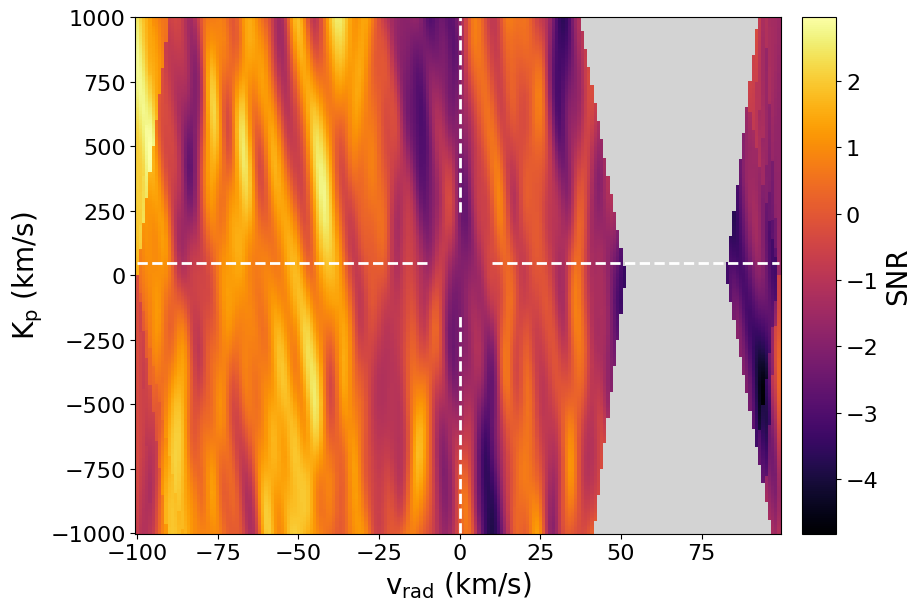

In [95]:
# CHOOSE METHOD
methods = [
        # 'ttest',
        # 'box',
        'clip'
          ]

# Choose Vrad (x-axis) Kp (y-axis) values for the plot
rv_grid = corrRV0
kp_grid = np.linspace(-1000, 1000, 400)

# Set Vrad and Kp limits for the box in the box method
box_Vrad = (100, 140)
box_Kp = (-60, -35)

# Set sigma limit and max number of iterations for the sigma-clipping method
clip_sigma = 2
clip_iter = 9


# PLOT THE CORRELATION MAP FOR EACH ORDER
plot_all_orders = False


# PLOT EACH ORDER OF THE MODEL
plot_model_orders = False
plot_these_orders = np.arange(10,12)  # 'all' or an array of specific orders


#----------------------------------------------------------------#

KpVrad_list = []

for visit_name in visits_plot:
    
    # Build the list of (npc, obs) to plot for this night
    if n_pc_plot is not None:  # plot a single reduction
        combos = [(n_pc_plot, all_obs[(visit_name, n_pc_plot)])]
        
    else:  # plot all reductions
        combos = [(npc, obs)
                  for (visit, npc), obs in all_obs.items()
                  if visit == visit_name]

    
    # Loop once over whatever we decided to plot
    for npc, obs in combos:
        print(f"\033[1m{visit_name} | nPC={npc}\033[0m")

        berv_rv = -obs.vrp - obs.mid_vrp - obs.RV_sys - (obs.mid_vr + obs.vr) - (obs.mid_berv + obs.berv)
        print(f"Tellurics should be at RV ≈ {np.mean(berv_rv):.1f}")


        # Choose what orders to plot
        order_indices = pf.select_orders_plot(obs, wave_mod, model_spec, orders_to_delete=orders_to_delete.get(visit_name),
                                              max_masked_ratio=max_masked_ratio, min_SNR=min_SNR, min_model_ppm=min_model_ppm)

        
        # Get the right ccf object
        ccf_obj = Correlations(all_ccf_map[(visit_name, npc)], kind="logl", rv_grid=corrRV0, n_pcas=npc, kp_array=Kp_array)
        ccf_obj.calc_ccf2d(obs, ccf=None, kind='logl_corr', id_pc=None, remove_mean=False, index=None, orders=order_indices)
        # ccf_obj.calc_logl(obs, orders=order_indices, index=None, N=None, nolog=False, icorr=obs.iIn, std_robust=True)


        if npc == 0:
            # Mask strong negative correlation regions
            ccf_sum = np.sum(ccf_obj.map_prf, axis=0)      # sum of CCFs over exposures
            noise_mask = (corrRV0 < -10) | (corrRV0 > 10)  # exclude RV region where planet signal is located
    
            # Calculate MAD of CCF sum (like a std dev but without outliers)
            ccf_sum_med = np.median(ccf_sum[noise_mask])
            mad = np.median(np.abs(ccf_sum[noise_mask] - ccf_sum_med))
    
            ccf_obj.map_prf[:, ccf_sum < ccf_sum_med - 4 * mad] = np.ma.masked   # mask negative outlier regions

        
        if 'ttest' in methods:
            ccf_obj.ttest_map(obs, kind='logl', vrp=np.zeros_like(obs.vrp), orders=order_indices, 
                          kp0=0, RV_limit=corr_xlim, kp_step=5, rv_step=2, RV=None, speed_limit=3,
                              icorr=obs.iIn, equal_var=False)
        
        if 'box' in methods:
            pf.calculate_KpVsys_map(obs, ccf_obj, method='box', rv_grid=rv_grid, kp_grid=kp_grid,
                        box_Vrad=box_Vrad, box_Kp=box_Kp)
        
        if 'clip' in methods:
            KpVrad_map = pf.calculate_KpVsys_map(obs, ccf_obj, method='clip', rv_grid=rv_grid, kp_grid=kp_grid,
                        clip_sigma=clip_sigma, clip_iter=clip_iter, title=False, output_map=True)
            KpVrad_list.append(KpVrad_map)

        if plot_all_orders:
            pf.plot_all_orders_correl(corrRV0, ccf_obj.data.squeeze(), obs, icorr=None, logl=False, sharey=True,
                              vrp=np.zeros_like(obs.vrp), RV_sys=0.0, vmin=None, vmax=None, vline=None,
                              hline=2, kind='snr', return_snr=False, orders=order_indices)

        if plot_model_orders:
            pdfname = fig_dir / f"model_plot_orderbyorder_{visit_name}_{reduc_version}_{npc}-pc_maskwings97_{model_name}.pdf"
            pf.plot_model_orders(obs, wave_mod, model_spec, order_indices, plot_these_orders=plot_these_orders,
                                 save_in_pdf=False, pdfname=pdfname)


# Combined

## Combined setup

In [88]:
# REDUCTION DETAILS
nPC = 0  # nPC to use

coeffs = [0.02703969,  1.10037972, -0.96372403,  0.28750393]  # limb darkening coefficients
ld_model = 'nonlinear'  # limb darkening model

# Where are the reductions
reduc_in_scratch = True  # in the scratch directory (True) or in the home directory (False)


# CORRELATION DETAILS
kind_trans = 'transmission'  # emission or transmission

# Define cross-correlation axes
step_RV_inj = 1.0  # SPIROU: 2.14 (twice the resolution of SPIRou in km/s); NIRPS: 1.0
corr_xlim = 100  # correlation will be done with Vrad values in [-corr_xlim, corr_xlim]

# Where to find the correlations
corr_in_scratch = True  # in the scratch directory (True) or in the home directory (False)


# NIGHTS TO COMBINE
file_arr = np.array([
                # SPIRou
                    # ['1', '2019-06-14', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2019-06-14.npz'],
                    # ['2', '2019-09-25', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2019-09-25.npz'],
                    # ['3', '2020-05-31', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-05-31.npz'],
                    # ['4', '2020-08-04', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-08-04.npz'],
                    # ['5', '2020-09-08', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-09-08.npz'],
                    # ['6', '2020-09-20', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-09-20.npz'],
                    # ['7', '2020-09-26', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-09-26.npz'],
                    # ['8', '2020-09-29', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-09-29.npz'],
                    # ['9', '2021-10-21', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2021-10-21.npz'],
                    # ['10', '2021-10-24', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2021-10-24.npz'],
                    # ['11', '2021-10-27', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2021-10-27.npz'],
                # NIRPS b
                    # ['1', '2023-09-07', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2023-09-07.npz'],
                    # ['2', '2024-07-05', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2024-07-05.npz'],
                    # ['3', '2024-07-11b', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2024-07-11b.npz'],
                # NIRPS d
                    # ['1', '2023-06-08', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2023-06-08.npz'],
                    # ['2', '2023-08-12', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2023-08-12.npz'],
                    # ['3', '2023-08-24', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2023-08-24.npz'],
                    # ['4', '2023-10-20', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2023-10-20.npz'],
                # NIRPS f
                    ['1', '2023-08-28', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2023-08-28.npz'],
                    ['2', '2024-11-02', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2024-11-02.npz'],
                    ['3', '2025-08-06', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2025-08-06.npz'],
                    ],
                   dtype=object)


## Run the combined correlation

In [89]:
pl_obs.log.setLevel("WARNING")  # do not print entire log in this cell


# Correlation setup
corrRV0 = np.arange(-corr_xlim, corr_xlim, step_RV_inj)  # x axis (Vrad)
combined_ccf = []
# combined_logl = []
combined_obs = []
visit_dict = dict()
all_visits_str = ""


for reduc_idx, reduc in enumerate(file_arr):
    
    visit_nb = reduc[0]
    visit = reduc[1]
    version = reduc[2]
    fname = reduc[3]

    
    print("Loading", visit, "correlation...")

    
    # Directory where the reductions are
    if reduc_in_scratch:
        base_dir = Path(os.environ['SCRATCH'])
    else:
        base_dir = Path.home() / "Github"
    
    reduc_dir = base_dir / Path(f'HRS_reductions/{instrument}/{pl_name_fname}/{visit}/{version}')


    # Directory where the correlations are
    if corr_in_scratch:
        corr_dir = Path(os.environ['SCRATCH']) / Path(f'HRS_correlations/{instrument}/{pl_name_fname}/{visit}')
    else:
        corr_dir = Path(f'/home/mathisb/Github/HRS_correlations/{instrument}/{pl_name_fname}/{visit}')

    # Create figures directory if it does not exist
    fig_dir = corr_dir / "Figures"
    fig_dir.mkdir(parents=True, exist_ok=True)


    # Redefine planet (since mid-tr time changes for each visit)
    mid_tr = mid_tr_dict[visit]

    pl_kwargs = {'M_star': M_star, 
                 'R_star': R_star,
                 'ap': ap,
                 'R_pl': R_pl,
                 'mid_tr': mid_tr,
                 't_peri': mid_tr,
                 'excent': e,
                 'w': w}

    planet_obj = Planet(pl_name, **pl_kwargs)
    obs = pl_obs.load_single_sequences(fname, pl_name, path=reduc_dir, load_all=False, filename_end='', plot=False, planet=planet_obj)

    
    out_filename = f'{Path(fname).stem}_{version}_ccf_logl_seq_{model_name}'

    
    try:
        # Check if already generated
        saved_values = np.load(corr_dir / Path(out_filename).with_suffix('.npz'))
        ccf_map = saved_values['corr']
        logl_map = saved_values['logl']

        
    except FileNotFoundError:
        # Generate 1d correlations  --  ccf_map shape: (n_exposures, n_order, n_Kp, n_vsys, n_pc, n_model)
        ccf_map, logl_map = corr.calc_logl_injred(obs,'seq', planet_obj, Kp_array, corrRV0, [nPC], wave_mod, model_spec, kind_trans)
        corr.save_logl_seq(corr_dir / Path(out_filename), ccf_map, logl_map, wave_mod, model_spec, nPC, Kp_array, corrRV0, kind_trans)
    
    all_visits_str += visit_nb + "-"
    
    visit_dict[str(reduc_idx + 1)] = obs
    combined_obs.append(obs)
    combined_ccf.append(ccf_map)
    # combined_logl.append(logl_map)


transit_tags = [np.arange(obs.n_spec) for obs in visit_dict.values()]
all_visits = pl_obs.gen_merge_obs_sequence(obs, visit_dict, np.arange(1, len(file_arr) + 1), None, coeffs, ld_model, kind_trans, light=True)
all_visits.dt = np.concatenate([vst.dt for vst in visit_dict.values()])  # exposure times
all_visits_str = all_visits_str[:-1]
visit_dict[all_visits_str.replace("-", "")] = all_visits


pl_obs.log.setLevel("INFO")  # go back to normal log printing

Loading 2023-08-28 correlation...
Loading 2024-11-02 correlation...
Loading 2025-08-06 correlation...


## Plot the combined correlation

In [90]:

# CRITERIA TO EXCLUDE AN ORDER

max_masked_ratio = 0.9  # excludes the orders where the ratio of masked data points is too high
min_SNR = 5            # excludes the orders where the instrument SNR is too low
min_model_ppm = 5       # excludes the orders where the model atmosphere is close to 0 ppm in transit depth

#-------------------------------------------------------------------------------------#


# Where to output the combined correlations
output_dir_comb = Path(os.environ['SCRATCH']) / Path(f'HRS_correlations/{instrument}/{pl_name_fname}/Combined/')

# Figures directory
fig_dir_comb = str(output_dir_comb) + "/Figures/"
Path(fig_dir_comb).mkdir(parents=True, exist_ok=True)

# Create filename for combined correlation file
args_filename = []
        
for i in range(len(file_arr)):
    args_filename.append((str(visit_dict[str(i + 1)].params[5]), str(int(visit_dict[str(i + 1)].params[1] * 100))))

args_filename = ['-'.join(values) for values in zip(*args_filename)]
filename = 'combined_corr_nights{}'.format(all_visits_str) + '_pc{}_mask_wings{}_'.format(*args_filename) + f"{model_name}"


# Get list of obs objects
obs_list = list(visit_dict.values())[:-1]

# Choose what orders to plot
comb_orders_to_delete = pf.combined_orders_to_delete(orders_to_delete, file_arr[:,1])
idx_orders = pf.select_orders_plot(obs_list, wave_mod, model_spec, orders_to_delete=comb_orders_to_delete,
                                      max_masked_ratio=max_masked_ratio, min_SNR=min_SNR, min_model_ppm=min_model_ppm)


# Create the CCF (combined) object
ccf_map_comb = np.concatenate(combined_ccf)
# logl_map = np.concatenate(combined_logl)

# ccf_obj_comb, logl_obj_comb = cc.plot_ccflogl(all_visits, 
#                                     ccf_map_comb,
#                                     logl_map,
#                                     corrRV0, np.array([obs.Kp.value]),
#                                     [nPC], orders=idx_orders,
#                                     path_fig=fig_dir_comb,
#                                     fig_name=filename,
#                                     cmap='viridis'
#                                    )


# # Plot the CCF
# ccf_obj_comb.ttest_map(all_visits, kind='logl', vrp=np.zeros_like(all_visits.vrp), orders=idx_orders, kp0=0, cmap='viridis',
#                   RV_limit=100, kp_step=5, rv_step=1, RV=None, speed_limit=3, icorr=all_visits.iIn, equal_var=False)


# Save combined correlation
pl_obs.save_sequences(filename, visit_dict, [int(all_visits_str.replace("-", ""))], path=output_dir_comb, print_out=False)


In [91]:

ccf_obj_comb = Correlations(ccf_map_comb, kind="logl", rv_grid=corrRV0, n_pcas=nPC, kp_array=np.array([obs.Kp.value]))
ccf_obj_comb.calc_ccf2d(all_visits, ccf=None, kind='logl_corr', id_pc=None, remove_mean=False, index=None, orders=idx_orders)

ccf_sum_mask_list = []

if nPC == 0:
    # Mask strong negative correlation regions
    for c in combined_ccf:
        ccf_sum = np.sum(np.sum(c.squeeze()[:, idx_orders], axis=1), axis=0)  # sum of CCFs over orders and exposures
        noise_mask = (corrRV0 < -10) | (corrRV0 > 10)  # exclude RV region where planet signal is located
    
        # Calculate MAD of CCF sum (like a std dev but without outliers)
        ccf_sum_med = np.median(ccf_sum[noise_mask])
        mad = np.median(np.abs(ccf_sum[noise_mask] - ccf_sum_med))
    
        ccf_sum_mask_list.append(ccf_sum < ccf_sum_med - 4 * mad)  # mask negative outlier regions
        
    combined_ccf_sum_mask = np.any(ccf_sum_mask_list, axis=0)
    ccf_obj_comb.map_prf[:, combined_ccf_sum_mask] = np.ma.masked


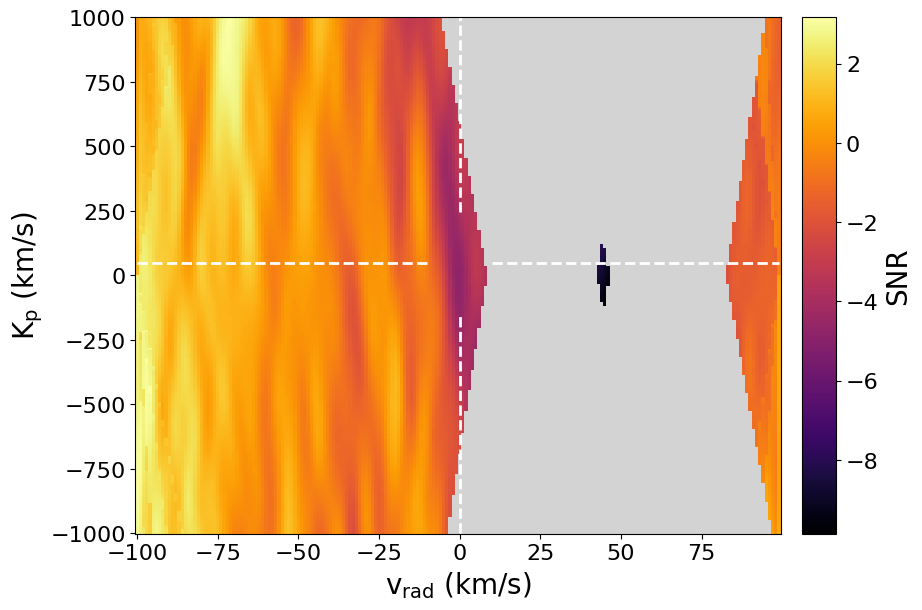

In [92]:
# BOX AND SIGMA-CLIPPING METHODS

# Choose Vrad (x-axis) Kp (y-axis) values
rv_grid = corrRV0
kp_grid = np.linspace(-1000, 1000, 400)

# # Set Vrad and Kp limits for the box in the box method
# box_Vrad = (75, 95)
# box_Kp = (-60, -35)

# Set sigma limit and max number of iterations for the sigma-clipping method
clip_sigma = 2
clip_iter = 9

# Save a figure
# save_box = None
save_clip = None  # directory and file name

#-------------------------------------------------------#

# Plot box and sigma-clipping methods
# pf.calculate_KpVsys_map(all_visits, ccf_obj_comb, method='box', rv_grid=rv_grid, kp_grid=kp_grid,
#                         box_Vrad=box_Vrad, box_Kp=box_Kp, savefig=save_box)
pf.calculate_KpVsys_map(all_visits, ccf_obj_comb, method='clip', rv_grid=rv_grid, kp_grid=kp_grid,
                        clip_sigma=clip_sigma, clip_iter=clip_iter, title=False, savefig=save_clip)

## Sensitivity vs number of transits (optional)

In [ ]:
# This was done one group of transits at a time (first running the combined corr. with 1 transit, then 2, then 3...).
# If done again, this would need to be adapted in some way and added into the code above, or the code above could be
# copied here and run just once to get the final plot.


# # Create lists of cross-correlation values
# nb_transits_list = []
# std_dev_list = []
# signal_str_list = []


# # GET CCF VALUES FOR EACH Vrad (to do in the code above)
# ccf_vals = ccf_obj.logl.squeeze()
# nb_transits_list.append(len(file_arr))


# # GET STD DEVIATION OF CCF OUTSIDE OF TRAIL
# # Get ccf values outside trail (v_rad = -150 to -100 and 100 to 150)
# ccf_outside_trail = np.concatenate((ccf_vals[:24], ccf_vals[117:]), axis=0)

# # Calculate std deviation
# ccf_std_dev = np.std(ccf_outside_trail)
# print(f"Standard deviation with {len(file_arr)} transits is", ccf_std_dev)

# std_dev_list.append(ccf_std_dev)


# # GET SIGNAL STRENGTH AT Vrad = 0
# # Get ccf values around Vrad = 0
# ccf_at_zero = ccf_vals[68:73]

# # Calculate mean signal
# ccf_mean = np.mean(ccf_at_zero)
# print(f"Mean ccf signal value with {len(file_arr)} transits is", ccf_mean)

# signal_str_list.append(ccf_mean)


# # Check that everything makes sense
# print(np.shape(ccf_vals))
# print(np.shape(ccf_outside_trail))
# print(np.shape(ccf_at_zero))

# plt.figure(figsize=(4.3,4))
# plt.plot(corrRV0, ccf_vals)  # should look like the CCF SNR plot above
# plt.show()

In [ ]:
# # PLOT NOISE AND SIGNAL VS NB OF TRANSITS
# std_dev_arr = np.array(std_dev_list) * 10e3
# signal_str_arr = np.array(signal_str_list) * 10e3

# plt.scatter(nb_transits_list, std_dev_arr, color="mediumblue", s=60, label="Standard deviation outside trail")
# plt.scatter(nb_transits_list, signal_str_arr, color="gold", s=60, label="Signal strength")

# plt.xlabel("Number of nights")
# plt.ylabel("Cross-correlation value [x$10^{3}$]")
# plt.legend()
# plt.show()